--- Patient Dataset Sample ---
   Age  Body_Mass_Index_BMI  Blood_Pressure_Systolic  Cholesterol_Level  \
0   51            28.239932                       97                206   
1   31            27.363985                      123                251   
2   37            30.779775                      105                180   
3   26            28.569880                      111                230   
4   43            26.117345                      146                262   

   Fasting_Blood_Sugar  Family_History  Smoking_Status  Disease_Present  
0                  145               1               0                1  
1                  134               0               0                1  
2                  108               0               0                1  
3                  116               1               0                1  
4                   92               0               0                0  

--- Preprocessing Medical Metrics ---

--- Training Model 1: Logistic Reg

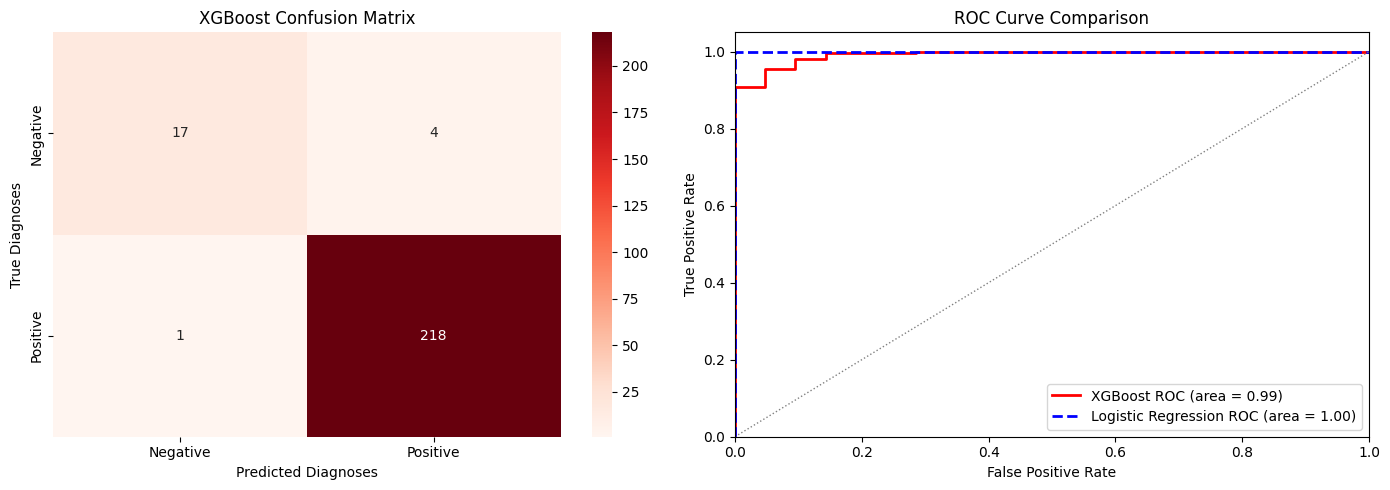

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

np.random.seed(101)
n_patients = 1200

medical_data = {
    'Age': np.random.randint(20, 80, size=n_patients),
    'Body_Mass_Index_BMI': np.random.uniform(18.5, 40.0, size=n_patients),
    'Blood_Pressure_Systolic': np.random.randint(90, 180, size=n_patients),
    'Cholesterol_Level': np.random.randint(150, 300, size=n_patients),
    'Fasting_Blood_Sugar': np.random.randint(70, 200, size=n_patients),
    'Family_History': np.random.choice([0, 1], size=n_patients, p=[0.6, 0.4]),
    'Smoking_Status': np.random.choice([0, 1], size=n_patients, p=[0.7, 0.3])
}

df_medical = pd.DataFrame(medical_data)

risk_score = (
    (df_medical['Fasting_Blood_Sugar'] / 100) * 2.5 +
    (df_medical['Body_Mass_Index_BMI'] / 25) * 1.5 +
    (df_medical['Blood_Pressure_Systolic'] / 120) * 1.2 +
    df_medical['Family_History'] * 1.8 +
    (df_medical['Age'] / 50)
)
df_medical['Disease_Present'] = (risk_score > 6.2).astype(int)

print("--- Patient Dataset Sample ---")
print(df_medical.head())

print("\n--- Preprocessing Medical Metrics ---")

X = df_medical.drop(columns=['Disease_Present'])
y = df_medical['Disease_Present']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n--- Training Model 1: Logistic Regression ---")
lr_model = LogisticRegression(random_state=101)
lr_model.fit(X_train_scaled, y_train)

print("--- Training Model 2: XGBoost Classifier ---")
xgb_model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=101, eval_metric='logloss')
xgb_model.fit(X_train_scaled, y_train)

print("\n================== XGBOOST MODEL EVALUATION ==================")
xgb_pred = xgb_model.predict(X_test_scaled)
xgb_prob = xgb_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, xgb_pred, target_names=['No Disease (0)', 'Disease Present (1)']))
xgb_auc = roc_auc_score(y_test, xgb_prob)
print(f"XGBoost ROC-AUC Score: {xgb_auc:.4f}")

print("\n================== LOGISTIC REGRESSION EVALUATION ==================")
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, lr_pred, target_names=['No Disease (0)', 'Disease Present (1)']))
lr_auc = roc_auc_score(y_test, lr_prob)
print(f"Logistic Regression ROC-AUC Score: {lr_auc:.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
cm_xgb = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Reds', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted Diagnoses')
plt.ylabel('True Diagnoses')

plt.subplot(1, 2, 2)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_prob)
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)

plt.plot(fpr_xgb, tpr_xgb, color='red', lw=2, label=f'XGBoost ROC (area = {xgb_auc:.2f})')
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2, linestyle='--', label=f'Logistic Regression ROC (area = {lr_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()